# **Module-Lattice-based Key-Encapsulation Mechanism (ML-KEM)**


## ein didaktisches Jupyter Notebook für den *Post-Quanten-Kryptografie-Standard ML-KEM*

#### erarbeitet von Long Pham unter der Betreuung von Prof. Dr. Martin Grüttmüller

---

# Ablauf des Notebooks

* ### [0. Literatur](#0)
* ### [1. Motivation und Einführung](#1)
* ### [2. Theoretische Grundlagen](#2)
* ### [3. Architektur und Gesamtablauf von ML-KEM](#3)
* ### [4. Effizienzsteigerung durch die Number Theoretic Transform (NTT)](#4)
* ### [5. Zusammenfassung](#5)


<br><br>
Ziel dieses Notebooks ist es, den ML-KEM Standard Schritt für Schritt zu erarbeiten. Dabei werden die theoretischen Konzepte direkt mit praktischen Beispielen und Visualisierungen verknüpft, um    

am Ende ein solides Grundverständnis für das Kryptografieverfahren und auch die theoretischen Hintergründe zu vermitteln. Das Notebook richtet sich primär an Studierende der Informatik/Mathematik.  

Es werden daher Grundkenntnisse in linearer Algebra und teilweise in der Polynomarithmetik vorausgesetzt, Vorkenntnisse in der Post-Quanten-Kryptografie sind jedoch nicht notwendig.<br><br>

>##### Für die optimale Nutzung empfiehlt es sich, dieses Notebook im Vollbildmodus anzuzeigen und bei Bedarf auch die linke Seitenleiste auszublenden.  
<br><br>

---

<a id="0"></a>
# 0. Literatur

Dieses didaktische Notebook basiert maßgeblich auf dem offiziellen Standard des *National Institute of Standards and Technology* (NIST):

* **NIST FIPS 203:** *Module-Lattice-Based Key-Encapsulation Mechanism Standard* (August 2024), https://nvlpubs.nist.gov/nistpubs/FIPS/NIST.FIPS.203.pdf

Die theoretischen Erklärungen, mathematischen Definitionen sowie die algorithmischen Abläufe wurden primär aus diesem Dokument entnommen und für diese Lernumgebung didaktisch aufbereitet.  

Weiterführende Quellen sind der schriftlichen Ausarbeitung zu entnehmen.
<br><br>

---
---

<a id="1"></a>
# 1. Motivation und Einführung
Diese Sektion dient als Einstieg in die Thematik und begründet die dringende Notwendigkeit neuer kryptografischer Standards wie ML-KEM. Von der Bedrohung unserer heutigen Verschlüsselungsverfahren

durch Quantencomputer über die Lösungsansätze der Post-Quanten-Kryptografie bis hin zum praktischen Einsatz von hybrider Verschlüsselung wird der notwendige Kontext geschaffen.  
<br><br>  
## 1.1 Bedrohung durch Quantencomputer
Die Sicherheit der modernen Kommunikation stützt sich aktuell maßgeblich auf asymmetrischen Kryptografieverfahren, wie RSA-, ECC- und Diffie-Hellman (DH). Sie basieren auf mathematischen Problemen  

(Primfaktorzerlegung, diskrete Logarithmen) die nicht in absehbarer Zeit von klassischen Computern gelöst werden können. Quantencomputer hingegen nutzen Prinzipien der Quantenmechanik (Superposition, Verschränkung)  

und können diese mathematischen Probleme in polynomieller Zeit brechen.  
<br><br>

Zwei Quantenalgorithmen sind hierbei besonders relevant:
* **Shor-Algorithmus:** Bricht RSA, ECC und DH theoretisch vollständig. Praktisch ist es nur eine Frage der Zeit, bis genügend leistungsfähige Quantencomputer existieren.

* **Grover-Algorithmus:** Schwächt symmetrische Verfahren wie AES aber bricht sie nicht vollständig. Hier ist ein Umstieg auf größere Schlüssel notwendig.  
<br><br>

Die Bedrohung für asymmetrische Verfahren ist **akut**, denn Angreifer nutzen das Angriffsverhalten ***Harvest Now, Decrypt Later***. Dabei speichern sie bereits heute verschlüsselte Daten (**Harvest**) um sie in Zukunft    

mit ausreichend fähigen Quantencomputern zu entschlüsseln (**Decrypt**). Besonders betroffen sind langlebige Daten, wie beispielsweise staatliche Informationen oder sensible Gesundheitsdaten.  
<br><br>

---

## 1.2 Lösung durch die Post-Quanten-Kryptografie
Die Grundidee der Post-Quanten-Kryptografie (PQC) ist der Einsatz von Verfahren, welche auf neuen mathematischen Problemen basieren, die auch **quantensicher** sind. Je nach zugrundeliegendem  

Problem lassen sich die Verfahren in verschiedene mathematische Familien einordnen, wie beispielsweise in die gitter-, hash- oder codebasierten Familien.<br><br>  

Um diese neuen Algorithmen zu finden initiierte das National Institute of Standards and Technology (NIST) im Jahr 2016 einen weltweiten Standardisierungsprozess. Dieser Evaluierungsprozess  

durchlief mehrere Runden, in denen Forschungsteams aus aller Welt ihre Algorithmen einreichten, um sie anschließend gegenseitig zu analysieren und auf Schwachstellen zu überprüfen.

Am Ende dieses Prozesses wurden aus ursprünglich 82 Einreichungen fünf finale Verfahren zur Standardisierung ausgewählt, welche in der folgenden Tabelle 1 zusammengefasst sind:  

<br><br>
<img src="bilder/nisttabelle.png">
<br><br>  
Aus der Tabelle wird ersichtlich, dass die gitterbasierten Verfahren derzeit die führende Rolle in der Post-Quanten-Kryptografie einnehmen. Damit auch andere Ansätze vorhanden sind, hat das NIST  

zur Absicherung bewusst HQC und SLH-DSA als Alternativen standardisiert, die auf anderen Problemen beruhen und somit als Sicherheit dienen sollen, falls Gitterprobleme doch gebrochen werden.  
<br><br>



---

## 1.3 Hybride Verschlüsselung und Nutzen von ML-KEM
In der modernen Kommunikation werden asymmetrische Verfahren mit symmetrischen Verfahren für eine ***hybride Verschlüsselung*** kombiniert: <br><br>
* **asymmetrische Verfahren** werden eingesetzt, um einen gemeinsamen Schlüssel als Nachricht auszutauschen. Dafür wird ein öffentlicher und ein privater Schlüssel verwendet.  

* **symmetrische Verfahren** nutzen diesen gemeinsam ausgetauschten Schlüssel, um die eigentlichen Daten zu verschlüsseln. Sie sind effizienter, benötigen aber diesen Schlüssel.  <br><br>

Der Standard ML-KEM dient genau diesem Schlüsselaustausch im ersten Punkt, ist dabei jedoch im Vergleich zu den heutigen klassischen Verfahren quantensicher.


Seine Sicherheit leitet er aus dem ***Module Learning with Errors*** Problem ab, das aus der ***Gittermathematik*** stammt und von künftigen Quantencomputern nach derzeitigem Stand nicht effizient lösbar sein wird.  
<br><br> 
Das Verständnis für Gitter sowie für das MLWE-Problem werden in der nächsten Notebook-Sektion [Theoretische Grundlagen](#2) aufgebaut.  
<br><br>  
<br><br>  

---
---

<a id="2"></a>
# 2. Theoretische Grundlagen  
Diese Sektion bildet schrittweise die mathematische Ausgangslage für den Standard ML-KEM. Beginnend bei mathematischen Gittern und den Gitterproblemen darin führt der Weg über das Learning with Errors Problem   

bis hin zum Module Learning with Errors Problem, auf dessen vermuteten Härte die Sicherheit des ML-KEM-Verfahrens basiert.
<br><br>  
## 2.1 Mathematisches Gitter
Ein Gitter $\mathcal{L}$ ist eine regelmäßige Anordnung von Punkten in einem $n$-dimensionalen Raum und wird als Menge aller ganzzahligen Linearkombinationen von ${n}$ linear unabhängigen Basisvektoren $\mathbf{b}_1, \mathbf{b}_2, \dots, \mathbf{b}_n$ definiert.  

Jeder Punkt im Gitter wird also durch eine Linearkombination dieser Basisvektoren repräsentiert und somit durch folgende Gleichung dargestellt:  
<br><br>
$\mathbf{v} = a_1\mathbf{b}_1 + a_2\mathbf{b}_2 + \dots + a_n\mathbf{b}_n \quad \text{mit } a_i \in \mathbb{Z}$  
<br><br>
Betrachten wir als Beispiel die Basis $B = \begin{pmatrix} 2 & -1 \\ 1 & 2 \end{pmatrix}$. Mit den Basisvektoren $b_1 = \begin{pmatrix} 2 \\ 1 \end{pmatrix}$ und $b_2 = \begin{pmatrix} -1 \\ 2 \end{pmatrix}$ wird folgendes Gitter erzeugt:


> **Code ausblenden:** Für einen besseren Lesefluss können die Codezellen am linken Seitenrand eingeklappt werden

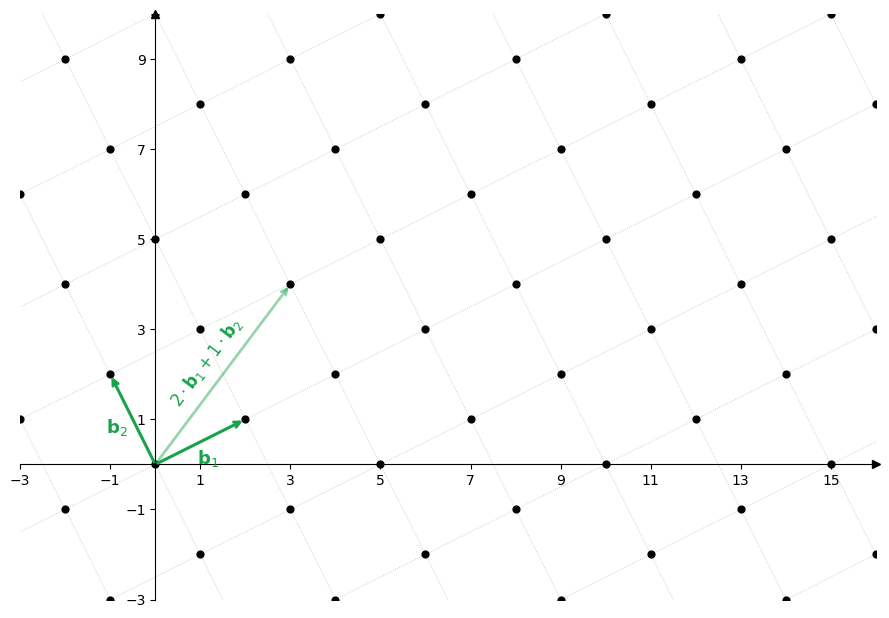

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ────────────────────────────────────────────────────────────────────────────────────────
#  Hier kann die Basis selbst gewählt werden, dafür die Basisvektoren b1 und b2 anpassen. 
#  !Die Vektoren müssen linear unabhängig sein! Standard: b1 = [2, 1], b2 = [-1, 2]
# ────────────────────────────────────────────────────────────────────────────────────────
b1 = np.array([ 2, 1])     # Basisvektor b1
b2 = np.array([-1, 2])     # Basisvektor b2
# ────────────────────────────────────────────────────────────────────────────────────────


def plot_lattice(basis, ax, farbe='#16a34a',
                 x_min=-3, x_max=16, y_min=-3, y_max=10, bereich=20):
    b1, b2 = basis[:, 0], basis[:, 1]

    grenze = max(abs(x_min), abs(x_max), abs(y_min), abs(y_max))
    punkte = np.array([i*b1 + j*b2 for i in range(-bereich, bereich+1)
                                   for j in range(-bereich, bereich+1)])
    punkte = punkte[(np.abs(punkte[:, 0]) <= grenze) & (np.abs(punkte[:, 1]) <= grenze)]

    for k in range(-bereich, bereich+1):
        for v, w in [(b1, b2), (b2, b1)]:
            start, ende = k*w - bereich*v, k*w + bereich*v
            ax.plot([start[0], ende[0]], [start[1], ende[1]],
                    ':', color='gray', lw=0.6, alpha=0.5)

    ax.scatter(punkte[:, 0], punkte[:, 1], s=24, color='black', zorder=3)

    for vektor, beschriftung, seite in [(b1, r'$\mathbf{b}_1$', -1),
                                        (b2, r'$\mathbf{b}_2$', +1)]:
        ax.annotate('', xy=vektor, xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color=farbe, lw=2.2))
        normale = np.array([-vektor[1], vektor[0]]) / np.linalg.norm(vektor) * 0.4 * seite
        ax.text(*(vektor/2 + normale), beschriftung, color=farbe, fontsize=13,
                fontweight='bold', ha='center', va='center')

    ax.set(xlim=(x_min, x_max), ylim=(y_min, y_max), aspect='equal',
           xticks=range(x_min, x_max+1, 2), yticks=range(y_min, y_max+1, 2))
    for s in ('left', 'bottom'): ax.spines[s].set_position('zero')
    for s in ('right', 'top'):   ax.spines[s].set_visible(False)
    ax.plot(1, 0, '>k', transform=ax.get_yaxis_transform(), clip_on=False, ms=6)
    ax.plot(0, 1, '^k', transform=ax.get_xaxis_transform(), clip_on=False, ms=6)

basis = np.column_stack([b1, b2])

if abs(np.linalg.det(basis)) < 1e-9:
    print("Die beiden Vektoren sind linear abhaengig - kein 2D-Gitter moeglich.")
else:
    fig, ax = plt.subplots(figsize=(9, 7))
    plot_lattice(basis, ax)

    #beispiel (3,4)
    if np.array_equal(b1, [2, 1]) and np.array_equal(b2, [-1, 2]):
        zielpunkt = 2 * b1 + b2
        ax.annotate('', xy=zielpunkt, xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color='#16a34a', lw=2.0, alpha=0.45))
        mitte   = zielpunkt / 2
        normale = np.array([-zielpunkt[1], zielpunkt[0]]) / np.linalg.norm(zielpunkt) * 0.45
        winkel  = np.degrees(np.arctan2(*zielpunkt[::-1]))
        ax.text(*(mitte + normale), r'$2 \cdot \mathbf{b}_1 + 1 \cdot \mathbf{b}_2$',
                color='#16a34a', fontsize=12, fontweight='bold',
                ha='center', va='center', rotation=winkel)

    plt.tight_layout()
    plt.show()

Der Gitterpunkt P(3,4) wird zum Beispiel durch die Linearkombination $2b_1 + 1b_2$ dargestellt. Es können in der Python-Zelle eigene beliebige Basen gewählt und das resultierende 2D Gitter angezeigt werden.  

Dabei muss jedoch beachtet werden, dass ganzzahlige Werte für die Basen eingegeben werden und dass die Basisvektoren $b_1$ und $b_2$ **linear unabhängig** voneinander sind, da sonst kein Gitter aufgespannt wird.  
<br><br>

Eine wichtige Eigenschaft von Gittern ist, dass das gleiche Gitter durch verschiedene Basen erzeugt werden kann:  

Das Gitter mit der Basis $B_1 = \begin{pmatrix} 2 & -1 \\ 1 & 2 \end{pmatrix}$ kann beispielsweise auch mit der Basis $B_2 = \begin{pmatrix} 5 & 7 \\ 5 & 6 \end{pmatrix}$ erzeugt werden. 
<br><br>  

---

## 2.2 Gitterprobleme
Die Sicherheit von gitterbasierten Kryptografieverfahren beruht auf der Schwierigkeit bestimmte Probleme in diesen Gittern zu lösen. In niedrigen Dimensionen (wie im 2D-Beispiel oben) sind diese 

visuell oder algorithmisch meist einfach zu lösen, in hochdimensionalen Räumen mit hunderten Dimensionen jedoch, sind die Probleme selbst für Quantencomputer praktisch unlösbar.  
<br><br>    

Zu den bekanntesten Gitterproblemen gehören unter anderem:  
* **Shortest Vector Problem (SVP):** Den kürzesten Vektor in einem Gitter finden (Nullvektor ausgenommen).

* **Closest Vector Problem (CVP):** Von einem Punkt im Raum, der ***kein*** Gitterpunkt ist, den am nächsten gelegenen Gitterpunkt im Raum finden.  
<br><br>  

Bei verschiedenen Problemvarianten des SVP wird vermutet, dass weder klassische Algorithmen noch Quantenalgorithmen existieren, die diese in hohen Dimensionen effizient lösen können. Da sich solche  

Gitterprobleme jedoch nicht für Verschlüsselungsalgorithmen eignen, wurde das **LWE-Problem** eingeführt woraus später das **Module Learning With Errors (MLWE)** folgte, auf das ML-KEM basiert.  

Für beide Probleme konnte bewiesen werden, dass sie genauso schwer zu lösen sind wie spezielle Varianten des SVP, womit letzteres als fundamentale Sicherheitsgrundlage fungiert.  
<br><br>  


---

## 2.3 Learning with Errors (LWE)
Das LWE-Problem basiert auf linearen Gleichungssystemen. 
* **klassisches LGS:** LGS ($\mathbf{A} \cdot \mathbf{s} = \mathbf{b}$) mittels Gauß-Algorithmus trivial nach s auflösbar

* **Modifikation durch LWE:** Zusätzlicher Fehlervektor $e$ ("Rauschen") und Verrechnung des Ergebnisses mit Modulo $q$

* **neue Gleichung:** $\mathbf{A} \cdot \mathbf{s} + \mathbf{e} \equiv \mathbf{b} \pmod q$, wobei $\mathbf{A}$ eine Matrix und $\mathbf{s}$, $\mathbf{e}$, $\mathbf{b}$ Vektoren sind

Mit dieser neuen Gleichung kann der geheime Vektor $\mathbf{s}$ nicht mehr mit dem Gauß-Algorithmus berechnet werden. 

Geometrisch lässt sich LWE als Gitterproblem interpretieren:
* Spalten der **Matrix $\mathbf{A}$** bilden Basisvektoren des Gitters

* Werte des **Vektor $\mathbf{s}$** sind die Koeffizienten mit denen die Basisvektoren kombiniert werden

* **Produkt $\mathbf{A} \cdot \mathbf{s}$** ergibt exakt einen Punkt auf dem Gitter  

* durch den **Fehler $\mathbf{e}$** wird dieser Punkt jedoch verschoben womit der resultierende Vektor $\mathbf{b}$ **keinen** Gitterpunkt mehr darstellt<br><br>  

Mathematisch ist die Suche nach $\mathbf{s}$ äquivalent zum Problem den nächstgelegenen Gitterpunkt von einem verschobenen Punkt zu finden, da somit der Fehler eliminiert und $\mathbf{s}$ trivial berechnet werden kann.   

Geometrisch entspricht das dem CVP Problem, welches visuell wie folgt aussieht:  
<br><br>

<img src="bilder/LWEgeo.png" style="width: 28%">
<br><br>  

Die Fehlerverteilung spielt dabei eine zentrale Rolle. Sind die Fehlerwerte zu klein, verliert das LWE seine Sicherheit und kann von Algorithmen wie *Arora-Ge* gebrochen werden. Sind die Werte jedoch  

zu groß, kann es beim Empfänger zu Entschlüsselungsfehlern durch den falschen Gitterpunkt kommen. Der Fehler $\mathbf{e}$ wird daher beim ML-KEM aus einer zentrierten Binomialverteilung gezogen.

Die folgende Visualisierung verbildlicht den Einfluss der Fehlerverteilung: 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

A = np.array([[2, -1], [1, 2]])
s = np.array([2, 1])
gitterpunkt = A @ s

a1, a2 = A[:, 0], A[:, 1]
gitter = np.array([i*a1 + j*a2 for i in range(-15, 16) for j in range(-15, 16)])


def zeichne_lwe(e_x, e_y):
    blau, rot = '#2563eb', '#dc2626'
    e = np.array([e_x, e_y])
    b = gitterpunkt + e

    abstaende = np.linalg.norm(gitter - b, axis=1)
    naechster = gitter[np.argmin(abstaende)]
    radius = abstaende.min()
    mehrdeutig = not np.allclose(naechster, gitterpunkt)

    fig, ax = plt.subplots(figsize=(7, 6))

    for k in range(-15, 16):
        for v, w in [(a1, a2), (a2, a1)]:
            ax.plot(*np.array([k*w - 15*v, k*w + 15*v]).T,
                    ':', color='gray', lw=0.6, alpha=0.5)
    sicht = gitter[(np.abs(gitter[:, 0]) <= 7) & (np.abs(gitter[:, 1]) <= 7)]
    ax.scatter(*sicht.T, s=24, color='black', zorder=3)

    def pfeil_mit_label(start, ziel, label, farbe, seite=+1, abstand=0.25):
        ax.annotate('', xy=ziel, xytext=start,
                    arrowprops=dict(arrowstyle='->', color=farbe, lw=2.0, alpha=0.5))
        richtung = ziel - start
        if np.linalg.norm(richtung) < 1e-6:
            return
        normale = np.array([-richtung[1], richtung[0]]) / np.linalg.norm(richtung) * abstand * seite
        winkel = np.degrees(np.arctan2(*richtung[::-1]))
        ax.text(*((start + ziel) / 2 + normale), label, color=farbe,
                fontsize=12, fontweight='bold',
                ha='center', va='center', rotation=winkel)

    pfeil_mit_label(np.zeros(2), gitterpunkt, r'$A \cdot s$', blau, seite=+1, abstand=0.25)
    ax.scatter(*gitterpunkt, s=80, color=blau, edgecolor='black', lw=1.0, zorder=5)

    pfeil_mit_label(np.zeros(2), b, r'$b = A \cdot s + e$', rot,
                    seite=-1, abstand=0.25)

    if np.linalg.norm(e) > 1e-6:
        ax.annotate('', xy=b, xytext=gitterpunkt,
                    arrowprops=dict(arrowstyle='->', color=rot, lw=1.8))
        normale = np.array([-e[1], e[0]]) / np.linalg.norm(e) * 0.3
        ax.text(*((gitterpunkt + b) / 2 + normale), r'$\mathbf{e}$',
                color=rot, fontsize=12, fontweight='bold', ha='center', va='center')

    ax.add_patch(plt.Circle(b, radius, fill=False, color=rot,
                            linestyle='--', lw=1.5, alpha=0.7))
    ax.scatter(*b, s=80, color=rot, edgecolor='black', lw=1.0, zorder=6)

    if mehrdeutig:
        ax.set_title("Fehler zu groß, nächstgelegener Punkt nicht mehr (3,4)",
                     color=rot, fontsize=11)

    ax.set(xlim=(-1, 7), ylim=(-1, 7), aspect='equal',
           xticks=range(-1, 8, 2), yticks=range(-1, 8, 2))
    for sp in ('left', 'bottom'): ax.spines[sp].set_position('zero')
    for sp in ('right', 'top'):   ax.spines[sp].set_visible(False)
    ax.plot(1, 0, '>k', transform=ax.get_yaxis_transform(), clip_on=False, ms=6)
    ax.plot(0, 1, '^k', transform=ax.get_xaxis_transform(), clip_on=False, ms=6)

    plt.tight_layout()
    plt.show()
    plt.close(fig)

interact(zeichne_lwe,
         e_x=FloatSlider(value=0.6, min=-2, max=2, step=0.2, description='e_x'),
         e_y=FloatSlider(value=-0.7, min=-2, max=2, step=0.2, description='e_y'));

interactive(children=(FloatSlider(value=0.6, description='e_x', max=2.0, min=-2.0, step=0.2), FloatSlider(valu…

---

## 2.4 Module Learning with Errors (MLWE)
<a id="24"></a>
Für kryptografisch relevante Gitterdimensionen (oft mehrere Hundert) ist das LWE-Problem nicht praxistauglich, da die Matrix mit jeder Dimension quadratisch wächst und jeder Eintrag gespeichert werden muss.

ML-KEM verwendet daher das weiterentwickelte MLWE-Problem, um den **Speicherbedarf** zu verringern.<br><br>
* MLWE nutzt statt einzelner Zahlen, Polynome aus dem Ring $R_q = \mathbb{Z}_q[X] / (X^n + 1)$, welcher für 2 Regeln sorgt:  
    - **Koeffizientengrenze**: Koeffizienten der Polynome werden Modulo $q$ gerechnet (für ML-KEM gilt fest $q=3329$)  
    - **Polynomlängengrenze**: Multiplikationen zwischen Polynomen werden modulo $(X^n + 1)$ brechnet, womit die Polynomlänge $n$ nicht überschritten wird
<br><br>
* ein einzelnes Polynom repräsentiert dabei **theoretisch** eine vollständig strukturierte $n\times n$ Matrix, welche durch anti-zyklische Verschiebungen der Koeffizienten abgeleitet werden kann  

* somit müssen für eine Matrix nur noch $n$ Einträge als Polynom gespeichert werden, anstatt alle $m \times n$ Einträge der Matrix
<br><br>  
  
Betrachtet man als Beispiel die Polynome $a(x)=7+9x+4x^2$ und $s(x)=1-2x+3x^2$ mit den Parametern $n=3$ und $q=8$, dann sieht eine Multiplikation unter dem Ring $R_q$ wie folgt aus:  
&nbsp;&nbsp;&nbsp;&nbsp;<small>(Notationshinweis: Polynome werden in der Kryptografie üblicherweise aufsteigend notiert)</small><br><br>  

* **1. Normale Multiplikation** (alles ausmultiplizieren): &nbsp; $(7+9x+4x^2) \cdot (1-2x+3x^2) =  7-5x+7x^2+19x^3+12x^4$  <br><br>

* **2. Polynomgrad reduzieren:** &nbsp;Da mod $(x^3+1)$ gerechnet wird, gilt $x^3+1 \equiv 0$, also $x^3 = -1$. Das heißt jedes $x^3$ wird mit $-1$ ersetzt: &nbsp; $-12-17x+7x^2$  <br><br>

* **3. Koeffizienten reduzieren:** jeder Koeffizienz wird Modulo $q=8$ gerechnet &nbsp;-> &nbsp; Ergebnis $4+7x+7x^2$  <br><br>  

>**Wichtig:** Die einfache Ersetzung von $x^n$ durch $-1/-c$ im **2.Schritt** ist ein Spezialfall und gilt nur bei Polynomringen der Form $\mathbb{Z}_q[X] / (X^n + 1)$ bzw. /$(X^n + c)$.  
Der Standard ML-KEM baut exakt auf dieser Struktur auf, weshalb sich die folgende Darstellung bewusst auf diesen relevanten Fall beschränkt.

<br><br>In der folgenden Zelle können zufällige Polynome generiert sowie multipliziert werden und die Schritte noch einmal mit einfachen Zwischenschritten nachvollzogen werden.<br><br>

In [3]:
import numpy as np
from ipywidgets import Button, Output, VBox, HBox, HTML, Layout
from IPython.display import display

n, q = 3, 8
FARBE = '#dc2626'

def poly_str(koeff):
    teile = []
    for i, c in enumerate(koeff):
        if c == 0:
            continue
        if i == 0:
            teile.append(f"{c}")
        elif i == 1:
            teile.append(f"{c}x" if c != 1 else "x")
        else:
            teile.append(f"{c}x^{i}" if c != 1 else f"x^{i}")
    return " + ".join(teile).replace("+ -", "- ") if teile else "0"

main_button = Button(
    description="Neue Polynome multiplizieren",
    button_style='', 
    layout=Layout(width='230px')
)
out = Output()
CSS_STYLE = """
<style>
.math-rounded-box {
    border: 1px solid #cbd5e1 !important;
    border-radius: 10px !important;
    background-color: #f8fafc !important;
    padding: 20px 30px !important;
    width: 720px !important;
    margin: 20px 0 20px 20px !important; 
}
</style>
"""
def multipliziere_und_zeige(button):
    a = np.random.randint(1, q, size=n)
    s = np.random.randint(1, q, size=n)

    voll = np.zeros(2 * n - 1, dtype=int)
    for i in range(n):
        for j in range(n):
            voll[i + j] += a[i] * s[j]
            
    step1_calc = f"({poly_str(a)}) &nbsp;&middot;&nbsp; ({poly_str(s)})"
    step1_final = poly_str(voll)

    reduce_subst = []
    for i in range(2 * n - 1):
        c = voll[i]
        if c == 0: continue
        if i < n:
            if i == 0: reduce_subst.append(f"{c}")
            elif i == 1: reduce_subst.append(f"{c}x")
            else: reduce_subst.append(f"{c}x^{i}")
        else:
            rem = i - n
            if rem == 0: reduce_subst.append(f"{c}(-1)")
            elif rem == 1: reduce_subst.append(f"{c}(-1)(x)")
            else: reduce_subst.append(f"{c}(-1)(x^{rem})")
    step2_subst = " + ".join(reduce_subst).replace("+ -", "- ")

    reduziert = voll[:n].copy()
    for i in range(n, 2 * n - 1):
        reduziert[i - n] -= voll[i]

    step2_final = poly_str(reduziert)

    ergebnis = reduziert % q
    mod_details = []
    for i in range(n):
        mod_details.append(f"{reduziert[i]} mod {q} = <b>{ergebnis[i]}</b>")
    step3_details = " &nbsp;|&nbsp; ".join(mod_details)

    html_start = HTML(CSS_STYLE + f"""
    <div style="font-family: monospace; font-size: 14px; line-height: 1.8;">
      <b style="font-size: 16px; color: #0f172a;">Start-Polynome:</b><br>
      a(x) = {poly_str(a)}<br>
      s(x) = {poly_str(s)}
    </div>
    """)
    param_html = HTML(f"""
    <div style="font-family: monospace; font-size: 14px; color: #334155; margin-bottom: 8px;">
      <b>Parameter:</b> n = {n}, q = {q}<br>
      <b>Ring:</b> &#8484;<sub>{q}</sub>[x]/(x<sup>{n}</sup>+1)
    </div>
    """)
    controls = VBox([param_html, main_button], layout=Layout(align_items='flex-end'))
    top_row = HBox([html_start, controls], layout=Layout(justify_content='space-between', width='100%', align_items='flex-start'))
    html_rest = HTML(f"""
    <div style="font-family: monospace; font-size: 14px; line-height: 1.8;">
      <hr style="border: none; border-top: 1px solid #cbd5e1; margin: 20px 0 35px 0;">
      <div style="margin-bottom: 35px;">
          <b style="font-size: 16px; color: #0f172a;">1. Klassisch ausmultiplizieren:</b><br>
          <span style="color: #64748b;">Ausrechnen:</span> {step1_calc}<br>
          <span style="color: #64748b;">Zwischenergebnis:</span> <b>{step1_final}</b>
      </div>
      <div style="margin-bottom: 35px;">
          <b style="font-size: 16px; color: #0f172a;">2. Polynomlängengrenze (x^{n} wird zu -1):</b><br>
          <span style="color: #64748b;">Einsetzen:</span> {step2_subst}<br>
          <span style="color: #64748b;">Zwischenergebnis:</span> <b>{step2_final}</b>
      </div>
      <div style="margin-bottom: 35px;">
          <b style="font-size: 16px; color: #0f172a;">3. Koeffizientengrenze:</b><br>
          <span style="color: #64748b;">modulo {q}:</span> {step3_details}
      </div>
      <span style="color: {FARBE}; font-weight: bold; font-size: 16px;">
        Ergebnis = {poly_str(ergebnis)}
      </span>
    </div>
    """)
    main_box = VBox([top_row, html_rest])
    main_box.add_class('math-rounded-box')
    with out:
        out.clear_output(wait=True)
        display(main_box)
main_button.on_click(multipliziere_und_zeige)
display(out)
multipliziere_und_zeige(None)

Output()

<br><br>
Der Standard ML-KEM fixiert nun die Polynomlänge auf **$n=256$**, womit jedes einzelne Polynom die Form $p(x) = a_0 + a_1x + a_2x^2 + a_3x^3 + \dots + a_{255}x^{255}$ besitzt.  

Um verschiedene Sicherheitsniveaus zu erreichen, werden die Polynome in einer kleinen $k \times k$ Matrix angeordnet. Bei ML-KEM gibt es drei Stufen mit $k=2, k=3, k=4$.  

Jeder Eintrag dieser Matrix ist ein Polynom. Folglich hat die Matrix $A$ in ML-KEM entweder 4, 9 oder 16 Polynome. Alle Vektoreneinträge sind ebenfalls Polynome.  
<br><br>  


Die Gleichung für das erste Sicherheitsniveau **ML-KEM-512 ($k=2$)** sieht somit wie folgt aus:

$
\begin{pmatrix} b_1(x) \\ b_2(x) \end{pmatrix} = \begin{pmatrix} a_{1,1}(x) & a_{1,2}(x) \\ a_{2,1}(x) & a_{2,2}(x) \end{pmatrix}\cdot \begin{pmatrix} s_1(x) \\ s_2(x) \end{pmatrix} + \begin{pmatrix} e_1(x) \\ e_2(x) \end{pmatrix} 
$  
  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $b$ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $A$ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $s$ &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; $e$  

Die Berechnung erfolgt nach klassischen Regeln. Die 1. Ergebniszeile ergibt sich aus der Gleichung &nbsp;
$b_1(x) = a_{1,1}(x) \cdot s_1(x) + a_{1,2}(x) \cdot s_2(x) + e_1(x)$  
<br><br>  

#### Der Speichereinfluss beim geringsten Niveau ML-KEM-512 für $A$:
* Matrix $A$ enthält **4 Polynome** mit $n=256$, ingesamt müssen nur 1024 Werte gespeichert werden
* zusammen repräsentieren die Polynome theoretisch eine große $512 \times 512$ Matrix:
    $ \left( \begin{array}{c|c} a_{1,1}(x) & a_{1,2}(x) \\ \hline a_{2,1}(x) & a_{2,2}(x) \end{array} \right) $
* ohne Polynome müssten also vier $256 \times 256$ Matrizen bzw. eine große $512 \times 512$ gespeichert werden, was ingesamt 262144 Werte sind  
<br><br>   

>**Ausblick:** Obwohl der Speicherbedarf verringert wird, bleibt der hohe Rechenaufwand. Wie die **Number Theoretic Transform(NTT)** dies löst und die Berechnungen beschleunigt, folgt in Sektion 4: [ Einfluss der NTT](#4)

<br><br>

---
---

<a id="3"></a>
# 3. Architektur und Gesamtablauf von ML-KEM
Nachdem in der vorherigen Sektion die theoretischen Grundlagen erarbeitet wurden, widmet sich diese Sektion dem eigentlichen Verfahren und seiner konkreten Konstruktion.  

Der Standard ML-KEM setzt sich aus einer zweistufigen Architektur zusammen: Ein internes asymmetrisches Verfahren als erste Stufe, auf das eine Transformation in der zweiten  

Stufe folgt, woraus dann schließlich die finalen Teilalgorithmen von ML-KEM hervorgehen. Im folgenden wird dieser gesamte Aufbau schrittweise beleuchtet und im Anschluss  

der praktische Gesamtablauf von ML-KEM anhand eines konkreten Rechenbeispiels visualisiert.  


 
<br><br>  

## 3.1 Internes K-PKE Verfahren


Das interne K-PKE Verfahren bildet die erste Stufe von ML-KEM. Hierbei handelt es sich um ein normales asymmetrisches Verfahren bestehend aus drei Algorithmen:  
* **Schlüsselerzeugung K-PKE.KeyGen():**
    * ein übergebener Wert wird gehasht und liefert zwei Seeds $\rho$ und $\sigma$
    * mit $\rho$ wird die öffentliche Matrix $A$ generiert (Einträge = Polynome), aus $\sigma$ werden die geheimen Vektoren $\mathbf{s}$, $\mathbf{e}$ erzeugt
    * Berechnung des Vektors $t$ über die MLWE-Gleichung $\mathbf{t} = \mathbf{A} \cdot \mathbf{s} + \mathbf{e}$ 
    * **Rückgabe:** öffentlicher Schlüssel $ek_{pke}$ bestehend aus ($\mathbf{t}$ || $\rho$), privater Schlüssel $dk_{pke}$ bestehend aus $\mathbf{s}$
<br><br>

* **Verschlüsselung K-PKE.Encrypt($ek_{pke}$):**
    * gewählte Nachricht $m$ wird mit $ek_{pke}$ (*encryption key*) in einen Chiffretext $c$ umgewandelt
    * dafür generiert der Algorithmus zusätzlich einen Vektor $\mathbf{y}$ sowie zwei Fehlervektoren $\mathbf{e}_1$ und $\mathbf{e}_2$
    * diese Werte werden mit $ek_{pke}$ verwendet um für den Chiffretext $c = (u, v)$ die Bestandteile $u$, $v$ zu berechnen
<br><br>

* **Entschlüsselung K-PKE.Decrypt($dk_{pke}$, $c$):**
    * Mithilfe des privaten Schlüssels $dk_{pke}$ (*decryption key*) wird ein Korrekturwert berechnet und von den Bestandteilen des Chiffretextes $c$ subtrahiert
    * das Resultat ist die ursprüngliche Nachricht, welche jedoch noch verrauscht ist
    * durch ein Rundungsverfahren wird das Rauschen entfernt und die Nachricht $m$ rekonstruiert

<small>Zur Verdeutlichung werden die beschriebenen Berechnungen bei der Ver- und Entschlüsselung in Abschnitt [3.4](#34) anhand eines konkreten Zahlenbeispiels durchgerechnet und visualisiert.</small>  
<br><br>  


Das K-PKE Verfahren ist alleine nicht sicher genug. Durch die Verschlüsselung schützt es vor Mitlesen der Nachricht (passive Angriffe), ist jedoch unsicher gegen aktive Angriffe, bei denen 

manipulierte Chiffretexte an den Empfänger geschickt werden, um aus der Reaktion Informationen zur Verarbeitung zu erlangen. Dies löst die **Fujisaki-Okamoto-Transformation**.

<br><br>

---

## 3.2 Fujisaki-Okamoto-Transformation (FO-Transformation)
Die Fujisaki-Okamoto-Transformation bildet die zweite Stufe des Aufbaus. Sie erfüllt zwei wichtige Aufgaben:<br><br>  
* **1. Wandlung von asymmetrischem Verfahren zum KEM:**
  Das asymmetrische K-PKE Verfahren verschlüsselt eine frei gewählte Nachricht, während ein KEM dazu dient, eigenständig einen  
  
  gemeinsamen Schlüssel für beide Seiten zu etablieren. Die Transformation sorgt für folgende Änderungen:<br><br>

  * Zufall statt Nachricht: es wird keine echte Nachricht mehr verschlüsselt, sondern ein zufällig generierter Seed  
  * Schlüsselableitung: aus dem Seed wird über eine Hashfunktion der finale gemeinsame Schlüssel $K$ sowie ein Zufallswert $r$ abgeleitet  
  * $r$ verschlüsselt den Seed $m$ zum Chiffretext $c$, dadurch wird die Verschlüsselung deterministisch (gleiche Eingaben führen zum gleichen Chiffretext, relevant für **2.**)
  * Empfänger entschlüsselt diesen und erhält den gleichen Seed, womit $K'$ und $r'$ abgeleitet werden 
<br><br>
* **2. Sicherheit gegen aktive Angreifer:**
  Um Manipulationen zu erkennen, führt der Empfänger bei der Entschlüsselung die **Re-Verschlüsselung** (*re-encryption*) mit $r'$ durch, nachdem er den Chiffretext $c$ entschlüsselt hat.     

  Dabei verschlüsselt er die Nachricht $m'$ erneut. Nur wenn der resultierende Chiffretext $c'$ exakt mit $c$ übereinstimmt, erhält der Empfänger den Schlüssel, ansonsten wird ihm ein falscher Schlüssel ausgegeben.  

  Damit ist es ununterscheidbar von einer erfolgreichen Entschlüsselung und der Angreifer erhält keine Informationen.  
<br><br>  





---

## 3.3 Die finalen ML-KEM Algorithmen
<img src="bilder/fips203KEM.png" alt="Einfache Darstellung KEM" style="float: right; width: 35%; margin-left: 40px; margin-right: 12%; margin-bottom: 5%;">

Auf Basis von K-PKE und der FO-Transformation werden die finalen ML-KEM Algorithmen definiert.   

Sie rufen die internen K-PKE Funktionen auf und koordinieren den Ablauf (siehe Abbildung rechts aus NIST FIPS 203)  

* **ML-KEM.KeyGen():**
  * generiert Seeds $d$, $z$
  * ruft intern `K-PKE.KeyGen(d)` auf, um Ver- und Entschlüsselungsschlüssel ($ek_{pke}$, $dk_{pke}$) zu generieren
  * $ek$ = $ek_{pke}$, $dk$ = $(dk_{pke}, ek_{pke},$ Hashwert $H(ek), z)$
<br>

* **ML-KEM.Encaps($ek$):**
  * generiert einen zufälligen Seed $m$
  * leitet über Hashfunktion aus $m$ den gemeinsamen Schlüssel $K$ und $r$ ab
  * ruft intern `K-PKE.Encrypt(ek_pke, m, r)` auf, um den Chiffretext $c$ zu erzeugen 
<br>

* **ML-KEM.Decaps($dk$, $c$):**
  * ruft intern `K-PKE.Decrypt(dk_pke, c)` auf, um Nachricht m' zu erhalten
  * leitet über Hashfunktion aus $m'$ den Schlüssel $K'$ und $r'$ ab
  * Re-Verschlüsselung mit `K-PKE.Encrypt(ek_pke, m, r)` zum Vergleich der Texte
  * **Vergleich:** bei $c == c'$, wird der korrekte Schlüssel $K'$ freigegeben,  
    sonst wird mit $z$ ein falscher Schlüssel generiert und als $K'$ ausgegeben
<div style="clear: both;"></div>

---

## 3.4 ML-KEM Gesamtablauf mit Rechenbeispiel
<a id="34"></a>
Nach der Theorie veranschaulicht die folgende Visualisierung den vollständigen Ablauf zur Etablierung des gemeinsamen Schlüssels.  
<br><br>

**Hinweise zur Visualisierung:**

* Ziel dieser Darstellung ist es, den strukturellen Ablaufs des Verfahrens greifbar zu machen. Daher werden komplexe Nebenfunktion, welche nicht zum grundlegenden Verständnis  

  beitragen aus didaktischen Gründen ausgelassen bzw. nur sehr verkürzt dargestellt. Für alle Funktionen siehe https://nvlpubs.nist.gov/nistpubs/FIPS/NIST.FIPS.203.pdf.
<br><br>
<br><br>  

* Das Verfahren wechselt stetig zwischen zwei Arraytypen
  * Bit-Arrays: Für Berechnungen mit Polynomen werden 12-Bit-Arrays (für $m$ 1-Bit-Array) verwendet, um alle Zahlen von 0 bis 3328 abbilden zu können. ($2^{11} = 2048 < q <  2^{12} = 4096$)
  * Byte-Arrays: Für Hashfunktionen oder die Datenübertragung benötigt es Byte-Arrays. Jede Stelle kann einen Wert von 0 bis 255 abbilden ($2^8=256$)
  
  * je nach Vorgang müssen die Arrays in Byte- oder Bit-Arrays umgewandelt werden. Zur optischen Vereinfachung werden Byte-Arrays mit zusätzlich **gestrichelten Linien** gekennzeichnet  
<br><br>  

In [ ]:
import hashlib
import numpy as np
import ipywidgets as widgets
from IPython.display import display
n      = 4
q      = 17
k      = 2
half_q = (q + 1) // 2
def poly_mul(a, b):
    """Multiplikation in R_q = Z_q[X] / (X^n + 1)."""
    res = np.zeros(n, dtype=int)
    for i in range(n):
        for j in range(n):
            if i + j < n:
                res[i + j] += a[i] * b[j]
            else:
                res[i + j - n] -= a[i] * b[j]
    return res % q
def poly_add(a, b): return (np.asarray(a) + np.asarray(b)) % q
def poly_sub(a, b): return (np.asarray(a) - np.asarray(b)) % q

def mat_vec_mul(M, v, transpose=False):
    out = [np.zeros(n, dtype=int) for _ in range(k)]
    for i in range(k):
        for j in range(k):
            a = M[j][i] if transpose else M[i][j]
            out[i] = poly_add(out[i], poly_mul(a, v[j]))
    return out

def vec_dot(v1, v2):
    out = np.zeros(n, dtype=int)
    for i in range(len(v1)):
        out = poly_add(out, poly_mul(v1[i], v2[i]))
    return out

def vec_add(v1, v2): return [poly_add(v1[i], v2[i]) for i in range(len(v1))]

def J(z, c_bytes):
    digest = hashlib.sha256(bytes(z) + bytes(c_bytes)).digest()
    return np.frombuffer(digest[:4], dtype=np.uint8)

A_DEMO = [[np.array([4, 11, 2, 8]), np.array([3, 1, 5, 2])],
          [np.array([2,  7, 9, 1]), np.array([6, 4, 3, 8])]]
S_DEMO = [np.array([1, 0, 1, 0]), np.array([0, 1, 0, 1])]
E_DEMO = [np.array([0, 1, 0, 0]), np.array([0, 0, 1, 0])]
Z_DEMO = bytes([9, 9, 9, 9])
M_DEMO  = np.array([1, 0, 1, 0])
K_DEMO  = np.array([42, 17, 88, 200], dtype=int)
R_DEMO  = [np.array([0, 1, 0, 0]), np.array([1, 0, 0, 0])]
E1_DEMO = [np.array([0, 0, 1, 0]), np.array([0, 1, 0, 0])]
E2_DEMO = np.array([0, 0, 0, 1])
COL_KEY    = "#61ff61"
COL_ENC    = "#61ff61"
COL_DEC    = "#61ff61"
COL_EVE    = "#dc3545"
COL_ACTIVE = "#61ff61"

def fmt_poly(p):
    """Polynom als wie sowas hier '[ 4, 11,  2,  8]'  (alle Koeffizienten modulo q)."""
    return "[" + ", ".join(f"{int(x % q):2d}" for x in p) + "]"
def fmt_bytes(arr):
    """für K"""
    return "[" + ", ".join(f"{int(x):3d}" for x in arr) + "]"
_TR  = 'style="background:transparent !important;"'
def _td(color, extra=""):
    return f'style="background:transparent !important; border-color:{color}; {extra}"'
def _bracket_table(rows_html):
    return (
        f'<table style="display:inline-table; border-collapse:collapse; '
        f'background:transparent !important; vertical-align:middle; margin:0 4px;">'
        f'{rows_html}</table>'
    )
def fmt_matrix_2x2(M, color="#333"):
    """Matrix mit ecken"""
    cs = "padding:3px 12px; font-family:monospace; text-align:center;"
    rows = ""
    for i in range(2):
        top = f"border-top:2px solid {color};"    if i == 0 else ""
        bot = f"border-bottom:2px solid {color};" if i == 1 else ""
        rows += (
            f"<tr {_TR}>"
            f'<td {_td(color, f"border-left:2px solid {color}; {top}{bot} width:6px;")}></td>'
            f'<td {_td(color, cs)}>{fmt_poly(M[i][0])}</td>'
            f'<td {_td(color, cs)}>{fmt_poly(M[i][1])}</td>'
            f'<td {_td(color, f"border-right:2px solid {color}; {top}{bot} width:6px;")}></td>'
            "</tr>"
        )
    return _bracket_table(rows)
def fmt_vector(v, color="#333"):
    cs = "padding:3px 12px; font-family:monospace; text-align:center;"
    rows = ""
    for i, p in enumerate(v):
        top = f"border-top:2px solid {color};"    if i == 0          else ""
        bot = f"border-bottom:2px solid {color};" if i == len(v) - 1 else ""
        rows += (
            f"<tr {_TR}>"
            f'<td {_td(color, f"border-left:2px solid {color}; {top}{bot} width:6px;")}></td>'
            f'<td {_td(color, cs)}>{fmt_poly(p)}</td>'
            f'<td {_td(color, f"border-right:2px solid {color}; {top}{bot} width:6px;")}></td>'
            "</tr>"
        )
    return _bracket_table(rows)
def fmt_row_vector(v, color="#333"):
    cs = "padding:3px 12px; font-family:monospace; text-align:center;"
    cols = "".join(f'<td {_td(color, cs)}>{fmt_poly(p)}</td>' for p in v)
    return (
        f'<table style="display:inline-table; border-collapse:collapse; '
        f'background:transparent !important; vertical-align:middle; margin:0 4px;">'
        f'<tr {_TR}>'
        f'<td {_td(color, f"border-left:2px solid {color}; border-top:2px solid {color}; border-bottom:2px solid {color}; width:6px;")}></td>'
        f'{cols}'
        f'<td {_td(color, f"border-right:2px solid {color}; border-top:2px solid {color}; border-bottom:2px solid {color}; width:6px;")}></td>'
        f'</tr></table>'
    )
def fmt_scalar(p, color="#333"):
    return (
        f'<span style="font-family:monospace; padding:3px 6px; '
        f'background:transparent;">{fmt_poly(p)}</span>'
    )
def fmt_key(K, color="#333"):
    return (
        f'<span style="font-family:monospace; padding:3px 6px; '
        f'border:1px dashed {color}; border-radius:3px; '
        f'background:transparent;">{fmt_bytes(K)}</span>'
    )
def label(name, color="#333"):
    return (
        f'<span style="font-family:Cambria,Georgia,serif; font-style:italic; '
        f'font-weight:bold; color:{color}; font-size:16px;">{name}</span>'
    )
def eq(*parts, gap="6px"):
    return (
        f'<div style="display:flex; align-items:center; flex-wrap:wrap; '
        f'gap:{gap}; margin:6px 0;">{"".join(parts)}</div>'
    )
def op(symbol):
    return f'<span style="font-size:20px; font-weight:bold; padding:0 4px;">{symbol}</span>'

state = {"manipulated": False}

def load_image_bytes(filename):
    try:
        with open(filename, "rb") as f:
            return f.read()
    except FileNotFoundError:
        return b''

html_params = widgets.HTML(
    value=("<div style='font-size:15px; padding-top:3px;'>"
           "<b>n = 4</b> &nbsp;|&nbsp; <b>q = 17</b> &nbsp;|&nbsp; <b>k = 2</b>"
           "</div>"),
    layout=widgets.Layout(width="28%"),
)

def make_btn(desc):
    return widgets.Button(
        description=desc,
        layout=widgets.Layout(
            width="20%",
            height="32px",
            border="1px solid #ccc",
            border_radius="6px",
        ),
        style={"button_color": "#f8f9fa"},
    )

btn_keygen = make_btn("1. KeyGen")
btn_encaps = make_btn("2. Encaps")
btn_decaps = make_btn("3. Decaps")
btn_encaps.disabled = True
btn_decaps.disabled = True
btn_eve = widgets.Button(
    description="Eve", 
    button_style="danger",
    layout=widgets.Layout(width="12%", height="32px", border_radius="6px", visibility="hidden"), 
)
top_bar = widgets.HBox(
    [html_params, btn_eve, btn_keygen, btn_encaps, btn_decaps],
    layout=widgets.Layout(justify_content="space-between",
                          align_items="center", margin="0 0 5px 0"),
)
img_widget = widgets.Image(
    value=load_image_bytes("bilder/abb3.png"),
    format="png",
    layout=widgets.Layout(width="85%"),
)
html_math = widgets.HTML(
    layout=widgets.Layout(width="auto", padding="15px",
                          background_color="#f8f9fa", border="none"),
)
html_math.value = (
    "<h3 style='color:#6c757d; text-align:center; margin-top:50px;'>"
    "Klicke links auf '1. KeyGen' um mehr über den Teilalgorithmus zu lernen.</h3>"
)
def set_active_button(active):
    for b in (btn_keygen, btn_encaps, btn_decaps):
        b.layout.border = "1px solid #ccc"
    active.layout.border = f"2px solid {COL_ACTIVE}"

def on_keygen(_):
    set_active_button(btn_keygen)
    img_widget.value = load_image_bytes("bilder/keygen.png")

    btn_eve.layout.visibility = "hidden"

    A, s, e = A_DEMO, S_DEMO, E_DEMO
    t = vec_add(mat_vec_mul(A, s), e)

    state.update(A=A, s=s, e=e, t=t, z=Z_DEMO)
    t_steps = (
        "<table style='display:inline-table; border-collapse:collapse; background:transparent !important; vertical-align:middle; margin:0 4px;'>"
        "<tr style='background:transparent !important;'>"
        "<td style='border-left:2px solid #333; border-top:2px solid #333; width:6px;'></td>"
        "<td style='padding:3px 8px; font-family:monospace; color:black; white-space:nowrap;'>"
        "A<sub>0,0</sub>&middot;s<sub>0</sub> + A<sub>0,1</sub>&middot;s<sub>1</sub> + e<sub>0</sub> &nbsp;=&nbsp; [&nbsp;2,&nbsp;&nbsp;3,&nbsp;&nbsp;6,&nbsp;&nbsp;2] + [14, 15, 16,&nbsp;&nbsp;8] + [&nbsp;0,&nbsp;&nbsp;1,&nbsp;&nbsp;0,&nbsp;&nbsp;0]"
        "</td>"
        "<td style='border-right:2px solid #333; border-top:2px solid #333; width:6px;'></td>"
        "</tr>"
        "<tr style='background:transparent !important;'>"
        "<td style='border-left:2px solid #333; border-bottom:2px solid #333; width:6px;'></td>"
        "<td style='padding:3px 8px; font-family:monospace; color:black; white-space:nowrap;'>"
        "A<sub>1,0</sub>&middot;s<sub>0</sub> + A<sub>1,1</sub>&middot;s<sub>1</sub> + e<sub>1</sub> &nbsp;=&nbsp; [10,&nbsp;&nbsp;6, 11,&nbsp;&nbsp;8] + [&nbsp;5,&nbsp;&nbsp;3, 13,&nbsp;&nbsp;9] + [&nbsp;0,&nbsp;&nbsp;0,&nbsp;&nbsp;1,&nbsp;&nbsp;0]"
        "</td>"
        "<td style='border-right:2px solid #333; border-bottom:2px solid #333; width:6px;'></td>"
        "</tr>"
        "</table>"
    )
    
    html_math.value = f"""
    <h1 style="margin-top:0; margin-bottom: 3%;">ML-KEM.KeyGen()</h1>
    <div style="background:white; padding:14px; border-left:3px solid {COL_KEY};">

        <p style="margin-bottom: 5px;"><b>1. Seeds <i>d</i> und <i>z</i> zufällig generieren:</b></p>
        {eq(
            label("d"), "=", 
            '<span style="font-family:monospace; padding:3px 6px; border:1px dashed #333; border-radius:3px;">[133,  24, 226,  13, 208, 105, 233, ...]</span>', 
            "&nbsp;&nbsp;&nbsp;&nbsp;", 
            label("z"), "=", 
            '<span style="font-family:monospace; padding:3px 6px; border:1px dashed #333; border-radius:3px;">[ 43, 111, 146, 187, 233,  26,  13, ...]</span>',
            "<span style='color:#666; font-size:14px; margin-left:8px;'>(in ML-KEM 32 Byte lang)</span>"
        )}

        <p><b>2. Internes K-PKE.KeyGen(d) aufrufen:</b><br>
        Aus dem Seed werden mittels Hashfunktion G die internen Seeds (&rho;, &sigma;) abgeleitet. Durch diese wiederum, werden <i>A</i>, <i>s</i> und <i>e</i> deterministisch erzeugt.</p>

        {eq(label("A"), "=", fmt_matrix_2x2(A))}

        {eq(label("s"), "=", fmt_vector(s),
            "&nbsp;&nbsp;", label("e"), "=", fmt_vector(e))}

        <p><b>2.1 In MLWE-Gleichung einsetzen:</b></p>

        {eq(label("t"), "=",
            label("A"), op("&middot;"), label("s"), op("+"), label("e"), 
            op("="), t_steps, 
            op("="), fmt_vector(t))}
            
        <div style="margin-top: 10px; border-radius: 4px; font-size: 13.5px;">
            Für eine Erklärung zur Berechnung von Polynomen siehe <b>Zelle 2.4 + Beispiel</b>.
        </div>
        <p><b>2.2 Rückgabe K-PKE.KeyGen(d):</b><br>
            asymmetrisches Schlüsselpaar (<i>ek</i><sub>pke</sub>, <i>dk</i><sub>pke</sub>), wobei <i>ek</i><sub>pke</sub> aus (<i>t</i>, <i>&rho;</i>) besteht und <i>dk</i><sub>pke</sub> = <i>s</i> entspricht.
        </p>
        <hr>
        <p><b>3. Rückgabe ML-KEM.Keygen:</b></p>
        <ul style="margin-top:0;">
            <li>Enkapselungsschlüssel &nbsp;<b><i>ek</i> = <i>ek</i><sub>pke</sub></b> &nbsp; <span style="color:gray;">öffentlicher Schlüssel, den Bob verwendet</span></li>
            <li>Dekapselungsschlüssel &nbsp;<b><i>dk</i> = (<i>dk</i><sub>pke</sub>, <i>ek</i><sub>pke</sub>, H(<i>ek</i>), <i>z</i>)</b> &nbsp; <span style="color:gray;">Alices geheimer Schlüssel</span></li>
        </ul>
        <div style="background-color: #f8f9fa; border-left: 3px solid #6c757d; padding: 10px 12px; margin-top: 20px; font-size: 13.5px; color: #495057; border-radius: 0 4px 4px 0;">
            <b>Hinweis:</b> In der Praxis werden die Ergebnispolynome in Byte-Arrays umgewandelt, damit sie übertragen und für Hashfunktionen verwendet werden können. Dies geschieht mit der Funktion 
            <b>ByteEncode</b> bzw. <b>ByteDecode</b> für die Rückwandlung in Bit-Arrays: <b><i>ek</i><sub>pke</sub> = ByteEncode<sub>12</sub>(<i>t</i>) &Vert; <i>&rho;</i></b><b>;</b> &nbsp; <b><i>dk</i><sub>pke</sub> = ByteEncode<sub>12</sub>(<i>s</i>)</b>.
        </div>
        
    </div>
    """
    btn_encaps.disabled = False

def on_encaps(_):
    set_active_button(btn_encaps)
    img_widget.value = load_image_bytes("bilder/encaps.png")

    btn_eve.layout.visibility = "visible"

    state["manipulated"] = False

    m_bits = M_DEMO
    m_bytes = np.array([5], dtype=int)
    
    K, y, e1, e2 = K_DEMO, R_DEMO, E1_DEMO, E2_DEMO
    r_seed = np.array([77, 12, 189, 42], dtype=int) 

    A_T = [[state["A"][0][0], state["A"][1][0]],
           [state["A"][0][1], state["A"][1][1]]]

    u = vec_add(mat_vec_mul(state["A"], y, transpose=True), e1)
    mu = (half_q * m_bits) % q
    v = (vec_dot(state["t"], y) + e2 + mu) % q

    state.update(m=m_bits, K=K, y=y, e1=e1, e2=e2, u=u, v=v)

    html_math.value = f"""
    <h1 style="margin-top:0; margin-bottom:1%;">ML-KEM.Encaps (ek)</h1>
    <div style="background:white; padding:14px; margin-top:2%; border-left:3px solid {COL_ENC};">

        <p style="margin-bottom: 5px;"><b>1. Zufälligen Seed <i>m</i> generieren:</b> In der Praxis ist dieser Seed 32 Byte lang, hier ist er 1 Byte lang.</p>
      
        {eq(
            label("m"), "=", fmt_key(m_bytes),
            "<span style='font-size:13.5px; margin-left:15px; line-height:1.4;'>Dieser Seed soll auf beiden Seiten den gleichen Zielschlüssel erzeugen und muss verschlüsselt an Alice gelangen.</span>"
        )}
        <p><b>2. Einsetzen von m und Hashwert H(ek) in Hashfunktion G(m &Vert; H(ek)):</b><br> 
        Mit der Hashfunktion G wird deterministisch der Zielschlüssel K sowie der Zufallswert r abgeleitet.</p>
      
        {eq(
            label("K"), "=", fmt_key(K),
            "&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;",
            label("r"), "=", fmt_key(r_seed),
        )}
        <p style="margin-top: 15px;"><b>3. Internes K-PKE.Encrypt(<i>ek</i><sub>pke</sub>, <i>m</i>, <i>r</i>) aufrufen:</b><br>
        Das <i>t</i> von <i>ek</i><sub>pke</sub> wird mittels <b>ByteDecode<sub>12</sub>(t)</b> in ein Bit-Array zurückgewandelt, mit dem Seed <i>&rho;</i> wird die gleiche Matrix <i>A</i> rekonstruiert.
        </p>

        <div style="display:flex; gap: 40px; align-items:center;">
            {eq(label("t"), "=", fmt_vector(state["t"]))}
            {eq(label("A"), "=", fmt_matrix_2x2(state["A"]))}
        </div>

        <p style="margin-top: 15px;"><b>3.1 Geheime Vektoren aus <i>r</i> sampeln:</b><br>
        Mit <i>r</i> werden über eine Hilfsfunktion die Fehler e1 und e2 sowie y aus einer <b>zentrierten Binomialverteilung</b> gezogen.</p>
        
        {eq(
            label("y"), "=", fmt_vector(y), 
            "&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;", 
            label("e1"), "=", fmt_vector(e1),
            "&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;", 
            label("e2"), "=", fmt_scalar(e2)
        )}

        <p style="margin-top: 20px; padding-bottom: 5px;"><b>3.2 Chiffretext c = (u, v) berechnen:</b></p>

        <div style="margin-top: 10px;">
            {eq(label("u"), "=", label("A"), op("ᵀ"), op("&middot;"), label("y"), op("+"), label("e1"))}
            {eq("&nbsp;&nbsp;=", fmt_matrix_2x2(A_T), op("&middot;"), fmt_vector(y), op("+"), fmt_vector(e1), "=", fmt_vector(u))}
        </div>

        <div style="margin-top: 10px;">
            {eq(label("v"), "=", label("t"), op("ᵀ"), op("&middot;"), label("y"), op("+"), label("e2"), op("+"), "&mu;", "<span style='color:#666; margin-left:10px; margin-top:6px'>(&mu; = &lceil;q/2&rfloor; &middot; ByteDecode<sub>1</sub>(m) = 9 &middot; [1, 0, 1, 0])</span>")}
            {eq("&nbsp;&nbsp;=", fmt_row_vector(state["t"]), op("&middot;"), fmt_vector(y), op("+"), fmt_scalar(e2), op("+"), fmt_scalar(mu), "=", fmt_scalar(v))}
        </div>
        <p style="margin-top: 10px; padding-bottom: 5px;"><b>3.3 Rückgabe K-PKE.Encrypt:</b><br>
        Chiffretext &nbsp;<b>c = (u, v)</b> mit <b>ByteEncode<sub>12</sub>(c)</b> für Byte-Array Form</p>
        <hr>
        <p style="margin-bottom: 5px;"><b>4. Rückgabe ML-KEM.Encaps:</b></p>
        <ul style="margin-top:0; display:flex; gap:40px; padding-left:20px;">
            <li>Chiffretext &nbsp;<b>c = (u, v)</b> &nbsp; <span style="color:gray;">geht an Alice</span></li>
            <li>Zielschlüssel &nbsp;<b>K</b> &nbsp; <span style="color:gray;">wird nicht verschickt (nur verschlüsselter Seed m in c)</span></li>
        </ul>
    </div>
    """
    btn_decaps.disabled = False
def on_eve(_):
    state["manipulated"] = True
    btn_eve.layout.visibility = "hidden"

    state["u"][0][0] = (state["u"][0][0] + 1) % q

    eve_hinweis = (
        f"<div style='background:#f8d7da; padding:10px 14px; margin-bottom:15px; font-size:14px;'>"
        f"<b style='color:{COL_EVE};'>Eve hat den Chiffretext manipuliert.</b> "
        f" Klicke auf <b>3. Decaps.</b>"
        f"</div>"
    )
    such_text = '<p style="margin-bottom: 5px;"><b>1. Zufälligen Seed'
    html_math.value = html_math.value.replace(such_text, eve_hinweis + such_text)

def on_decaps(_):
    set_active_button(btn_decaps)
    img_widget.value = load_image_bytes("bilder/decaps.png")
    btn_eve.layout.visibility = "hidden"
    su = vec_dot(state["s"], state["u"])
    w  = (state["v"] - su) % q
    m_prime = np.zeros(n, dtype=int)
    for i, val in enumerate(w):
        m_prime[i] = 1 if abs(int(val) - half_q) < min(int(val), q - int(val)) else 0

    m_prime_bytes = np.array([int(m_prime[0]*1 + m_prime[1]*2 + m_prime[2]*4 + m_prime[3]*8)])
    K_prime, r_prime, e1_prime, e2_prime = K_DEMO, R_DEMO, E1_DEMO, E2_DEMO
    r_prime_seed = np.array([77, 12, 189, 42], dtype=int)
    u_prime = vec_add(mat_vec_mul(state["A"], r_prime, transpose=True), e1_prime)
    v_prime = (vec_dot(state["t"], r_prime) + e2_prime + half_q * m_prime) % q
    c_bytes = np.concatenate([np.concatenate(state["u"]), state["v"]])
    K_bar   = J(state["z"], c_bytes)
    u_match  = all(np.array_equal(state["u"][i], u_prime[i]) for i in range(k))
    v_match  = np.array_equal(state["v"], v_prime)
    is_valid = u_match and v_match
    
    if is_valid:
        K_out = K_prime
        status = (
            f"<div style='background:#d4edda; color:#155724; padding:12px; margin-top:10px;'>"
            f"<h3 style='margin:0 0 6px 0;'>Geprüft: c = c'</h3>"
            f"Zielschlüssel <b>K'</b> = <b>"f"{fmt_bytes(K_out)}</b> wird freigegeben. Ein symmetrischer Schlüssel konnte erfolgreich etabliert werden.</div>"
        )
    else:
        K_out = K_bar
        status = (
            f"<div style='background:#f8d7da; color:#721c24; padding:12px; margin-top:10px;'>"
            f"<h3 style='margin:0 0 6px 0;'>Geprüft: c &ne; c'</h3>"
            f"Die <b>implicit rejection</b> tritt ein: <b>K'</b> wird der Wert von <b>K&#772</b> zugeordnet und "
            f"<b>{fmt_bytes(K_out)}</b> als falscher Schlüssel ausgegeben.</div>"
        )
    u_html = fmt_vector(state["u"])
    u_prime_html = fmt_vector(u_prime)
    v_html = fmt_scalar(state["v"])
    v_prime_html = fmt_scalar(v_prime)
    vergleichs_zeichen = "="

    if not is_valid:
        vergleichs_zeichen = "&ne;"
        u_html = u_html.replace("12", "<span style='color:red; font-weight:bold;'>12</span>", 1)
        u_prime_html = u_prime_html.replace("11", "<span style='color:red; font-weight:bold;'>11</span>", 1)


    html_math.value = f"""
    <h1 style="margin-top:0; margin-bottom: 3%;">ML-KEM.Decaps (dk, c)</h1>
    <div style="background:white; padding:14px; border-left:3px solid {COL_DEC};">

        <p><b>1. Bestandteile aus dem <i>dk</i>-Byte-Array extrahieren:</b> &nbsp;&nbsp; <i>dk</i><sub>pke</sub>, <i>ek</i><sub>pke</sub>, H(<i>ek</i>), <i>z</i></p>
        <p style="margin-bottom: 5px;"><b>2. Internes K-PKE.Decrypt(<i>dk</i><sub>pke</sub>, <i>c</i>) aufrufen:</b></p>
        <p style="margin-top: 0; font-size: 14px;"><i>u</i>, <i>v</i> werden entnommen und mittels <b>ByteDecode<sub>12</sub></b> für Berechnungen in 12 Bit-Arrays umgewandelt. Das gleiche bei <i>dk</i><sub>pke</sub> womit man Vektor <i>s</i> hat.</p>
        {eq(label("u"), "=", fmt_vector(state["u"]), "&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;", label("v"), "=", fmt_scalar(state["v"]), "&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;", label("s"), "=", fmt_vector(state["s"]))}

        <p style="margin-top: 15px; margin-bottom: 5px;"><b>2.1 In Gleichungen einsetzen und Nachricht m' entnehmen:</b></p>
        
        {eq("w =", label("v"), op("&minus;"), label("s"), op("ᵀ"), op("&middot;"), label("u"), 
            "=", fmt_scalar(state["v"]), op("&minus;"), fmt_row_vector(state["s"]), op("&middot;"), fmt_vector(state["u"]), 
            "=", fmt_scalar(w))}
        {eq(
            label("m'"), 
            "=", 
            f"<b>ByteEncode<span style='font-size:0.8em; position:relative; top:0.25em;'>1</span></b>( <b>Runden</b>({fmt_scalar(w)}))", 
            "=", 
            f"<b>ByteEncode<span style='font-size:0.8em; position:relative; top:0.25em;'>1</span></b>({fmt_scalar(m_prime)})", 
            "=", 
            fmt_key(m_prime_bytes)
        )}
        <div style="margin-bottom: 15px; font-size: 13.5px;">
            Beim <b>Runden</b> werden Werte näher an der Mitte (q/2 &approx; 9), zu 1 und Werte näher an 0 oder q, zu 0.
        </div>

        <p style="margin-top: 15px; margin-bottom: 5px;"><b>3. Einsetzen von m' und Hashwert H(ek) in Hashfunktion G(m' ‖ H(ek)) und Berechnung des falschen Schlüssels:</b><br>
        Mit der Hashfunktion G wird deterministisch der Zielschlüssel K' sowie der Zufallswert r' abgeleitet. Mit der Hashfunktion J wird der falsche Schlüssel K&#772; berechnet.</p>
        
        {eq(label("K'"), "=", fmt_key(K_prime), "&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;", label("r'"), "=", fmt_key(r_prime_seed), "&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;", label("K&#772;"), "=", label("J(z &Vert; c)"), "=", fmt_key(K_bar))}

        <p style="margin-top: 15px; margin-bottom: 5px;"><b>4. Re-Verschlüsselung mittels K-PKE.Encrypt(<i>m'</i>, <i>r'</i>, <i>ek</i><sub>pke</sub>) und Vergleich:</b><br>
        Empfänger berechnet neuen Chiffretext <i>c'</i>. Falls <i>c'</i> mit <i>c</i> übereinstimmt, wird der Zielschlüssel <i>K'</i> freigegeben, andernfalls folgt die <b>implicit rejection.</b></p>

        {eq(
            label("<i>c</i>(<i>u</i>, <i>v</i>)"), "=", u_html, v_html, 
            "&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;", 
            op(vergleichs_zeichen), 
            "&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;", 
            label("<i>c'</i>(<i>u</i>, <i>v</i>)"), "=", u_prime_html, v_prime_html
        )}
        <hr>
        <p style="margin-top: 15px; margin-bottom: 0;"><b>5. Rückgabe ML-KEM.Decaps:</b></p>
        {status}
    </div>
    """

btn_keygen.on_click(on_keygen)
btn_encaps.on_click(on_encaps)
btn_eve.on_click(on_eve)
btn_decaps.on_click(on_decaps)

left_column = widgets.VBox(
    [
        top_bar,
        widgets.HTML("<hr style='border:0; border-top:1px solid #ccc; "
                     "margin:0 -10px 10px -10px;'>"),
        img_widget,
    ],
    layout=widgets.Layout(width="40%", padding="10px",
                          border_right="2px solid #ccc"),
)

right_column = widgets.VBox(
    [html_math],
    layout=widgets.Layout(width="60%", padding="10px 0 0 10px"),
)

dashboard = widgets.HBox(
    [left_column, right_column],
    layout=widgets.Layout(background_color="white"),
)

display(dashboard)

<br><br>  
---
---
---


# 4. Effizienzsteigerung durch die Number Theoretic Transform (NTT)<a id="4"></a>
Die finale Sektion thematisiert die Leistungsoptimierung von ML-KEM durch die NTT. Da die wiederholte Polynommultiplikation den größten Rechenaufwand darstellt, ist die Transformation für den Standard essentiell. 

Dabei wird zunächst auf die grundlegende Funktionsweise der NTT eingegangen und anschließend ihr Einfluss mit einer Gegenüberstellung der beiden Multiplikationen verdeutlicht.  
<br><br>  
# 4.1 Funktionsweise der NTT
Bisher wurde die Polynommultiplikation klassisch betrachtet, heißt jeder Koeffizient des einen Polynoms muss mit jedem des anderen Polynoms multipliziert werden, was $256 \times 256 = 65.536$ Rechenschritte erfordert.  

Um dies zu beschleunigen verwendet das Verfahren ML-KEM die **NTT**, welche als eine spezialisierte Variante der *diskreten Fourier-Transformation* betrachtet werden kann. 
<br><br>   

* **Ziel der NTT:** Die aufwendige Multiplikation zweier großer Polynome $a$ und $b$ durch eine Zerlegung vereinfachen

    * Dafür werden die Polynome in die ***NTT-Domäne*** überführt und dabei in kleine Teilpolynome zerlegt. Alle Teilpolynome eines Polynoms $f$ werden als Einträge in einem Array $\hat{f}$ gespeichert.  
    
    * Damit werden in der NTT-Domäne die Teilpolynomen aus $\hat{a}$ separat und komponentenweise mit den Teilpolynomen aus $\hat{b}$ multipliziert.   

    * Die resultierenden Teilpolynome werden abschließend durch die inverse NTT-Funktion zurück in ein normales Polynom transformiert.  
      
      Das Ergebnispolynom $c= a \cdot b$ würde über den gesamten NTT-Weg durch folgende Gleichung berechnet werden: $c = \text{NTT}^{-1}(\text{NTT}(a) \circ \text{NTT}(b))$  
<br><br>
* **Bedingung:** Damit ein Polynom $p(x) = a_0 + a_1x + a_2x^2 + \dots + a_{255}x^{255}$ vollständig in 256 Skalare zerlegt werden kann, wird eine 512. Einheitswurzel benötigt (ein Wert $\zeta$, für den $\zeta^{512} \equiv 1$ gilt),  

    * In $Z_{3329}$ existiert kein Wert $\zeta$ dafür.  
* **Zerlegung in Teilpolynome:** Es gibt jedoch 256. Einheitswurzeln, für ML-KEM ist das beispielsweise $\zeta=17$ sodass $17^{256} \equiv 1 \pmod{3329}$
    * damit werden Polynome in 128 Teilpolynome vom Grad 1 zerlegt

<br><br>

Die folgenden Zelle skizziert das Grundprinzip der NTT zur reinen Veranschaulichung. Eine detaillierte Beschreibung kann im offiziellen NIST-Dokument vorgefunden werden: https://nvlpubs.nist.gov/nistpubs/FIPS/NIST.FIPS.203.pdf.
<br><br>  


In [ ]:
from IPython.display import display, HTML

CSS_STYLE = """
<style>
.output-container {
    width: 100%;
    background-color: #ffffff;
    padding: 30px 0 30px 30px;
}
.math-rounded-box {
    border: 1px solid #cbd5e1;
    border-radius: 10px;
    background-color: #f8fafc;
    padding: 25px 35px;
    font-family: monospace; 
    font-size: 14px; 
    line-height: 1.8;
    color: #0f172a; 
}
.math-title {
    font-size: 16px; 
    font-family: sans-serif;
}
.math-grid {
    display: grid;
    grid-template-columns: auto auto auto auto auto auto auto;
    column-gap: 8px;
    row-gap: 8px;
    align-items: center;
    text-align: center;
}
</style>
"""

html_content = """
<div class="output-container">
    <div class="math-rounded-box">
        
        <div style="display: flex; justify-content: space-between; align-items: flex-end; margin-bottom: 15px;">
            <div class="math-title"><b>Polynome a, b &isin; R<sub>q</sub>:</b></div>
            <div style="font-family: sans-serif; font-size: 15px;">
                R<sub>q</sub> = &#8484;<sub>3329</sub>[X]/(X<sup>256</sup>+1)
            </div>
        </div>
        
        <div style="margin-bottom: 15px;">
            a(x) = a<sub>0</sub> + a<sub>1</sub>x + a<sub>2</sub>x<sup>2</sup> + a<sub>3</sub>x<sup>3</sup> + &hellip; + a<sub>255</sub>x<sup>255</sup><br>
            b(x) = b<sub>0</sub> + b<sub>1</sub>x + b<sub>2</sub>x<sup>2</sup> + b<sub>3</sub>x<sup>3</sup> + &hellip; + b<sub>255</sub>x<sup>255</sup>
        </div>
        
        <hr style="border: none; border-top: 1px solid #cbd5e1; margin: 25px 0 25px 0;">
        
        <div style="margin-bottom: 25px; white-space: nowrap;">
            <b style="font-size: 16px;">1. NTT(a):</b> <span style="color: #64748b;">Zerlegung von a in 128 Teilpolynome der Form a&#770;[2i] + a&#770;[2i + 1]X, f&uuml;r i=0 bis i=127</span><br>
            a&#770; = ( a&#770;<sub>0</sub> + a&#770;<sub>1</sub>x, &nbsp; a&#770;<sub>2</sub> + a&#770;<sub>3</sub>x, &nbsp; &hellip; , &nbsp; a&#770;<sub>254</sub> + a&#770;<sub>255</sub>x )
        </div>

        <div style="margin-bottom: 30px; white-space: nowrap;">
            <b style="font-size: 16px;">2. NTT(b):</b> <span style="color: #64748b;">Zerlegung von b in 128 Teilpolynome der Form b&#770;[2i] + b&#770;[2i + 1]X, f&uuml;r i=0 bis i=127</span><br>
            b&#770; = ( b&#770;<sub>0</sub> + b&#770;<sub>1</sub>x, &nbsp; b&#770;<sub>2</sub> + b&#770;<sub>3</sub>x, &nbsp; &hellip; , &nbsp; b&#770;<sub>254</sub> + b&#770;<sub>255</sub>x )
        </div>

        <div style="margin-bottom: 30px;">
            <b style="font-size: 16px;">3. c&#770; = a&#770; &#8728; b&#770;:</b> <span style="color: #64748b;">Separate, komponentenweise Multiplikation der Teilpolynome</span><br>
            
            <div style="display: flex; flex-direction: row; align-items: center; justify-content: flex-start; margin-top: 20px; margin-left: 30px;">
                
                <div style="font-size: 16px; font-weight: bold;">c&#770; = &nbsp;</div>
                
                <div style="font-size: 65px; font-weight: 300; font-family: sans-serif; line-height: 0.7; margin-right: 8px;">(</div>
                
                <div class="math-grid">
                    
                    <div style="grid-row: 1; grid-column: 1; text-align: right;">(</div>
                    <div style="grid-row: 1; grid-column: 2;">a&#770;<sub>0</sub> + a&#770;<sub>1</sub>x</div>
                    <div style="grid-row: 1; grid-column: 3; font-size: 14px;">,</div>
                    <div style="grid-row: 1; grid-column: 4;">a&#770;<sub>2</sub> + a&#770;<sub>3</sub>x</div>
                    <div style="grid-row: 1; grid-column: 5; font-size: 14px;">, &hellip; ,</div>
                    <div style="grid-row: 1; grid-column: 6;">a&#770;<sub>254</sub> + a&#770;<sub>255</sub>x</div>
                    <div style="grid-row: 1; grid-column: 7; text-align: left;">)</div>

                    <div style="grid-row: 2; grid-column: 2; font-size: 16px;"><span style="display: inline-block; transform: scaleY(1.8); margin-right: 4px;">&darr;</span> <b style="font-size: 20px;">&middot;</b></div>
                    <div style="grid-row: 2; grid-column: 4; font-size: 16px;"><span style="display: inline-block; transform: scaleY(1.8); margin-right: 4px;">&darr;</span> <b style="font-size: 20px;">&middot;</b></div>
                    <div style="grid-row: 2; grid-column: 6; font-size: 16px;"><span style="display: inline-block; transform: scaleY(1.8); margin-right: 4px;">&darr;</span> <b style="font-size: 20px;">&middot;</b></div>

                    <div style="grid-row: 3; grid-column: 1; text-align: right;">(</div>
                    <div style="grid-row: 3; grid-column: 2;">b&#770;<sub>0</sub> + b&#770;<sub>1</sub>x</div>
                    <div style="grid-row: 3; grid-column: 3; font-size: 14px;">,</div>
                    <div style="grid-row: 3; grid-column: 4;">b&#770;<sub>2</sub> + b&#770;<sub>3</sub>x</div>
                    <div style="grid-row: 3; grid-column: 5; font-size: 14px;">, &hellip; ,</div>
                    <div style="grid-row: 3; grid-column: 6;">b&#770;<sub>254</sub> + b&#770;<sub>255</sub>x</div>
                    <div style="grid-row: 3; grid-column: 7; text-align: left;">)</div>
                    
                </div>
                
                <div style="font-size: 65px; font-weight: 300; font-family: sans-serif; line-height: 0.7; margin-left: 8px;">)</div>
            </div>
        </div>

        <div style="margin-top: 35px; color: #dc2626;">
            <b style="font-size: 16px;">4. Endergebnis c = NTT<sup>-1</sup>(c&#770;) = c<sub>0</sub> + c<sub>1</sub>x + c<sub>2</sub>x<sup>2</sup> + c<sub>3</sub>x<sup>3</sup> + &hellip; + c<sub>255</sub>x<sup>255</sup></b>
        </div>
    </div>
</div>
"""

display(HTML(CSS_STYLE + html_content))

---

## 4.2 Effizienzvergleich: Klassische Multiplikation vs. Multiplikation mit NTT

Um den Einfluss der NTT auf die Effizienz zu verdeutlichen, stellt die folgende Zelle den Rechenaufwand beider Berechnungen visuell gegenüber. 

Der generierte Graph vergleicht die Anzahl der benötigten Rechenoperationen in Abhängigkeit von der Größe der Polynome.  
<br><br>

Hierbei handelt es sich um eine rein theoretische Betrachtung und nicht um gemessene Werte.
<br><br>

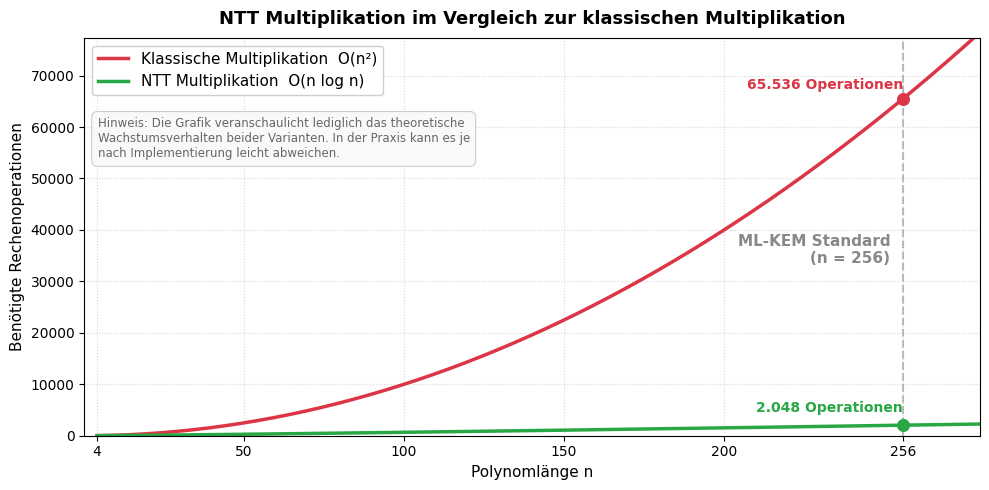

In [6]:
import numpy as np
import matplotlib.pyplot as plt
N_MAX = 280
n_kem = 256
x = np.arange(4, N_MAX + 1)
y_normal = x ** 2
y_ntt    = x * np.log2(x)
ops_normal = int(n_kem ** 2)
ops_ntt    = int(n_kem * np.log2(n_kem))
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y_normal, color='#dc3545', linewidth=2.5,
        label='Klassische Multiplikation  O(n²)')
ax.plot(x, y_ntt, color='#28a745', linewidth=2.5,
        label='NTT Multiplikation  O(n log n)')
ax.axvline(x=n_kem, color='gray', linestyle='--', alpha=0.5)
ax.scatter([n_kem], [ops_normal], color='#dc3545', s=70, zorder=5)
ax.scatter([n_kem], [ops_ntt],    color='#28a745', s=70, zorder=5)
ax.annotate('ML-KEM Standard\n(n = 256)',
            xy=(n_kem, ops_normal),
            xytext=(252, ops_normal * 0.55),
            fontsize=11, fontweight='bold', color='#888',
            ha='right', va='center')
ax.annotate(f'{ops_normal:,}'.replace(',', '.') + ' Operationen',
            xy=(n_kem, ops_normal),
            xytext=(n_kem, ops_normal + 1350),
            fontsize=10, fontweight='bold', color='#dc3545',
            ha='right', va='bottom')
ax.annotate(f'{ops_ntt:,}'.replace(',', '.') + ' Operationen',
            xy=(n_kem, ops_ntt),
            xytext=(n_kem, ops_ntt + 1900),
            fontsize=10, fontweight='bold', color='#28a745',
            ha='right', va='bottom')
ax.text(0.015, 0.8,
        'Hinweis: Die Grafik veranschaulicht lediglich das theoretische\n'
        'Wachstumsverhalten beider Varianten. In der Praxis kann es je\n'
        'nach Implementierung leicht abweichen.',
        transform=ax.transAxes, fontsize=8.5, color='#666',
        va='top', ha='left',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#f8f9fa',
                  edgecolor='#ccc', linewidth=0.8))
ax.set_xticks([4, 50, 100, 150, 200, 256])
ax.set_xlim(0, N_MAX)
ax.set_ylim(0, ops_normal * 1.18)
ax.set_title("NTT Multiplikation im Vergleich zur klassischen Multiplikation",
             fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel("Polynomlänge n", fontsize=11)
ax.set_ylabel("Benötigte Rechenoperationen", fontsize=11)
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95,
)
plt.tight_layout()
plt.show()

Die Grafik veranschaulicht, wie der Rechenaufwand bei der klassischen Multiplikation mit wachsendem Parameter $n$ quadratisch ansteigt, während bei der NTT-Multiplikation der Graph deutlich    

flacher verläuft. Für den vom Standard ML-KEM festgelegten Parameter $n=256$ wird die Anzahl der theoretisch benötigten Rechenoperationen enorm durch die NTT reduziert.

---

# 5. Zusammenfassung<a id="5"></a>

Zum Abschluss der Bearbeitung sind im Folgenden zur Verinnerlichung die wichtigsten Kerninhalte der vorangegangenen Sektionen kompakt zusammengefasst: 
<br><br>
### 1. Motivation 
* **Quantenbedrohung:** Zukünftige Quantencomputer werden in der Lage sein, klassische asymmetrische Verschlüsselungsverfahren zu brechen.  

* **Lösung Post-Quanten-Verfahren:** Um die Sicherheit zu erhalten, wurden neue quantenresistente Verfahren wie ML-KEM gesucht und vom NIST als Standard veröffentlicht.
<br><br>
### 2. Theoretische Grundlagen 
* **Gitterbasierte Kryptografie:** ML-KEM gehört zur Familie der gitterbasierten Verfahren, welche aktuell mit 3 von 5 standardisierten Verfahren die führende Rolle in der Post-Quanten-Kryptografie einnehmen.  

* **Sicherheit:** Die Sicherheit des Standards ML-KEM basiert auf der vermuteten Härte des MLWE-Problems, dessen Härte wiederum auf der Schwierigkeit von bestimmten Gitterproblemen basiert.  

* **MLWE-Problem:** Eine Erweiterung des LWE-Problems, die auf Polynomringen und somit auf Polynomen anstatt auf einzelnen Zahlen basiert. Durch die Ringstruktur wird der Speicherbedarf verringert  

   und die dazugehörige Polynommultiplikation ermöglicht zudem eine hohe Verringerung des Rechenaufwands durch die NTT.
<br><br>
### 3. Architektur und Ablauf 
* **Zweistufiger Aufbau** Der Standard setzt sich aus einer zweistufigen Architektur zusammen. Die erste Stufe bildet das klassisches asymmetrisches Verfahren K-PKE, welches in der nächsten Stufe durch die  
  
  Fujisaki-Okamoto-Transformation die notwendige Sicherheit erlangt und zusätzlich das Verfahren zu einem KEM erweitert.  

* **Schlüsselaustausch:** Mit den beiden Stufen entsteht der finale KEM. Aufgabe von ML-KEM ist es, einen gemeinsamen Schlüssel für beide Seiten zu etablieren, um einen zukünftigen Datenaustausch zu ermöglichen.
<br><br>
### 4. Effizienzsteigerung durch die NTT
* **Hoher Rechenaufwand:** Die klassische Multiplikation von Polynomen erfordert viele Rechenschritte und stellt für den Standard einen hohen Rechenaufwand dar. Mit der NTT wird der Rechenaufwand enorm verringert.   

* **NTT:** Die transformiert die zu multiplizierenden Polynome in die NTT-Domäne und zerlegt sie dabei in kleine Teilpolynome. Die zusammengehörenden Teilpolynome werden anschließend separat und komponentenweise  

  miteinander multipliziert und die daraus resultierenden Teilpolynome für das Ergebnis in den Ring zurücktransformiert.